# 快速入门

本快速入门演示如何使用 LangGraph Graph API 或 Functional API 构建一个计算器 agent。

- 如果你更倾向于把 agent 定义为由 nodes 与 edges 组成的 graph, 请使用 Graph API。
- 如果你更倾向于把 agent 定义为单个函数, 请使用 Functional API。

概念性说明请参阅 [Graph API overview](https://docs.langchain.com/oss/langgraph/graph-api) 与 [Functional API overview](https://docs.langchain.com/oss/langgraph/functional-api)。

In [1]:
# 环境准备: 从 .env 加载 API keys
from dotenv import load_dotenv

load_dotenv()  # 自动向上查找仓库根目录的 .env

# ---- 统一导入 ----
import operator
from typing import Literal

from typing_extensions import TypedDict, Annotated

from langchain.chat_models import init_chat_model
from langchain.messages import (
    AnyMessage,
    SystemMessage,
    ToolMessage,
    HumanMessage,
    ToolCall,
)
from langchain.tools import tool
from langchain_core.messages import BaseMessage
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.func import entrypoint, task

In [2]:
from IPython.display import display, Image
from langgraph.graph.state import CompiledStateGraph

def show_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))

from rich import print as rprint


## 使用 Graph API

### 1. 定义 tools 与 model

在本示例中, 我们使用 DeepSeek 的 chat model, 并定义加法、乘法与除法的 tools。

In [3]:
model = init_chat_model("deepseek:deepseek-chat", temperature=0)


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

### 2. 定义 state

graph 的 state 用于存储 messages 以及 LLM 的调用次数。

> **提示**
>
> LangGraph 中的 state 在整个 agent 执行期间持续存在。
>
> 配合 `operator.add` 使用的 `Annotated` 类型可确保新 messages 追加到现有列表中, 而不是替换整个列表。

In [4]:
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

### 3. 定义 model node

model node 用于调用 LLM, 并决定是否调用 tool。

In [5]:
def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }

### 4. 定义 tool node

tool node 用于调用 tools 并返回结果。

In [6]:
def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

### 5. 定义结束逻辑

conditional edge 函数用于根据 LLM 是否发起了 tool call, 决定路由到 tool node 还是结束。

In [7]:
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

### 6. 构建并编译 agent

该 agent 使用 `StateGraph` 类构建, 并使用 `compile` 方法编译。

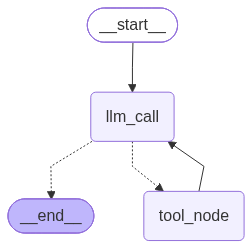

HumanMessage(content='Add 3 and 4.', additional_kwargs={}, response_metadata={})

AIMessage(
    content='',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 52,
            'prompt_tokens': 471,
            'total_tokens': 523,
            'completion_tokens_details': None,
            'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 256},
            'prompt_cache_hit_tokens': 256,
            'prompt_cache_miss_tokens': 215
        },
        'model_provider': 'deepseek',
        'model_name': 'deepseek-flash',
        'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
        'id': '358a5f44-71a7-4708-85b6-c0b8046a4f22',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--01a0facd-36a9-7ef2-8b9a-21c361be8963-0',
    tool_calls=[
        {'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_00_f2crh0jPtIn9JjC8J68c7094', 'type': 'tool_call'}
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 471,
        'output_tokens': 52,
        'total_tokens': 523,
        'input_token_details': {'cache_read': 256},
        'output_token_details': {}
    }
)

ToolMessage(content='7', tool_call_id='call_00_f2crh0jPtIn9JjC8J68c7094')

AIMessage(
    content='3 + 4 = 7',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 7,
            'prompt_tokens': 536,
            'total_tokens': 543,
            'completion_tokens_details': None,
            'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 384},
            'prompt_cache_hit_tokens': 384,
            'prompt_cache_miss_tokens': 152
        },
        'model_provider': 'deepseek',
        'model_name': 'deepseek-flash',
        'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
        'id': 'c1f2b9b5-21e4-4ef1-af3f-cc30f872cda1',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--01a0facd-3a92-7160-85e0-83b29e38460e-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 536,
        'output_tokens': 7,
        'total_tokens': 543,
        'input_token_details': {'cache_read': 384},
        'output_token_details': {}
    }
)

In [8]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
show_graph(agent)

# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    rprint(m)

恭喜! 你已经使用 LangGraph Graph API 构建了第一个 agent。

## 使用 Functional API

### 1. 定义 tools 与 model

Functional API 使用的 tools 与 model 与上一节完全相同, 已在上文定义, 此处直接复用。

### 2. 定义 model node

model node 用于调用 LLM, 并决定是否调用 tool。

> **提示**
>
> `@task` 装饰器把函数标记为一个可以作为 agent 一部分执行的 task。Tasks 可以在 entrypoint 函数内以同步或异步方式调用。

In [9]:
@task
def call_llm(messages: list[BaseMessage]):
    """LLM decides whether to call a tool or not"""
    return model_with_tools.invoke(
        [
            SystemMessage(
                content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
            )
        ]
        + messages
    )

### 3. 定义 tool node

tool node 用于调用 tools 并返回结果。

In [10]:
@task
def call_tool(tool_call: ToolCall):
    """Performs the tool call"""
    tool = tools_by_name[tool_call["name"]]
    return tool.invoke(tool_call)

### 4. 定义 agent

该 agent 使用 `@entrypoint` 函数构建。

> **注意**
>
> 在 Functional API 中, 你不必显式定义 nodes 与 edges, 而是在单个函数内编写标准的控制流逻辑(循环、条件分支)。

In [11]:
@entrypoint()
def agent(messages: list[BaseMessage]):
    model_response = call_llm(messages).result()

    while True:
        if not model_response.tool_calls:
            break

        # Execute tools
        tool_result_futures = [
            call_tool(tool_call) for tool_call in model_response.tool_calls
        ]
        tool_results = [fut.result() for fut in tool_result_futures]
        messages = add_messages(messages, [model_response, *tool_results])
        model_response = call_llm(messages).result()

    messages = add_messages(messages, model_response)
    return messages

In [12]:
# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
stream = agent.stream_events(messages, version="v3")
for snapshot in stream.values:
    rprint(snapshot)
    rprint("\n")

C:\Users\Ashit\Documents\GitHub\LangChain-Docs\.venv\Lib\site-packages\langgraph\pregel\main.py:3708: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return self._pregel_stream_v3(
C:\Users\Ashit\Documents\GitHub\LangChain-Docs\.venv\Lib\site-packages\langgraph\pregel\main.py:3558: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return GraphRunStream(graph_iter, mux)


[
    HumanMessage(
        content='Add 3 and 4.',
        additional_kwargs={},
        response_metadata={},
        id='f0e0a906-655e-4a4c-a055-2b0d1f34962e'
    ),
    AIMessage(
        content=[
            {
                'type': 'tool_call',
                'id': 'call_00_Xvw9mAb5vONI02SPF3b50648',
                'name': 'add',
                'args': {'a': 3, 'b': 4}
            }
        ],
        additional_kwargs={},
        response_metadata={
            'model_provider': 'deepseek',
            'finish_reason': 'tool_calls',
            'model_name': 'deepseek-flash',
            'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
            'output_version': 'v1'
        },
        id='lc_run--01a0facd-3d47-7f23-a315-b1970bf1b92d',
        tool_calls=[
            {
                'name': 'add',
                'args': {'a': 3, 'b': 4},
                'id': 'call_00_Xvw9mAb5vONI02SPF3b50648',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 471,
            'output_tokens': 52,
            'total_tokens': 523,
            'input_token_details': {'cache_read': 256}
        }
    ),
    ToolMessage(
        content='7',
        name='add',
        id='6992838e-7b42-4e8e-9802-9110d18659bf',
        tool_call_id='call_00_Xvw9mAb5vONI02SPF3b50648'
    ),
    AIMessage(
        content=[{'type': 'text', 'text': '3 + 4 = 7', 'index': 0}],
        additional_kwargs={},
        response_metadata={
            'model_provider': 'deepseek',
            'finish_reason': 'stop',
            'model_name': 'deepseek-flash',
            'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
            'output_version': 'v1'
        },
        id='lc_run--01a0facd-404d-7690-a1c0-eb080aca0375',
        tool_calls=[],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 536,
            'output_tokens': 7,
            'total_tokens': 543,
            'input_token_details': {'cache_read': 384}
        }
    )
]

恭喜! 你已经使用 LangGraph Functional API 构建了第一个 agent。